### CS4423 - Networks
Prof. Götz Pfeiffer<br />
School of Mathematics, Statistics and Applied Mathematics<br />
NUI Galway

**Name:** Cian Mac Liatháin
**ID:** 11476078

# Assignment 5

Provide answers to the problems in the boxes provided.  

The buttons at the top of the page can be used to **create
more boxes if needed**.
The type of box can be changed from `Code` to `Markdown`.
`Code` boxes take (and execute) `python` code.
`Markdown` boxes take (and format nicely) **text input**.
In this way, you can provide answers, ask questions, 
or raise issues, in words.

Some marks will be awarded for
participation and engagement.

When finished, print this notebook into a **pdf** file and submit this to
**blackboard**.

**Deadline** is this **Friday** at 5pm.

## Setup

This is a `jupyter` notebook.   You can open and interact
with the notebook through one of sites recommended at
its [github](https://github.com/gpfeiffer/cs4423) repository.

Or, you can
install and use `jupyter` as a `python` package on your own laptop or PC.  

The following command loads the `networkx` package into the current session.  
The next command specifies some standard options that can be useful for drawing graphs.  

In order to execute the code in a box,
use the mouse or arrow keys to highlight the box and then press SHIFT-RETURN.

In [321]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
opts = { "with_labels": True, "node_color": 'y' }

Should it ever happen that the notebook becomes unusable, start again with a fresh copy.

## 1.  A Citation Network

The file `scientometrics.net` contains a representation of a network of citations between the $1656$ articles that
appeared from 1978 to 2004 in [Scientometrics](https://en.wikipedia.org/wiki/Scientometrics_(journal)), 
a journal devoted to the field of bibliometrics and the "Science of Science".  It is loaded into a graph `G`
as follows.

In [322]:
E = nx.read_edgelist("data/scientometrics.net", create_using=nx.DiGraph, nodetype=int)
G = nx.DiGraph()
G.add_nodes_from(range(1, 1656))
G.add_edges_from(E.edges())

`G` as **a lot of nodes** and even more edges:  **Don't draw** this network.

In [323]:
m, n = G.order(), G.size()
m, n

(1655, 4123)

The file `scientometrics_paper_year.txt` contains, for most but not all articles in the network, 
their year of publication.  It is loaded and stored as node attributes as follows

In [324]:
years = np.loadtxt("data/scientometrics_paper_year.txt", dtype="int")
for date in years:
    G.nodes[date[0]]['year'] = date[1]

Now most nodes have their publication year as value of the `'year'` key in their attributes dictionary.
For example, node $1113$.

In [325]:
G.nodes[1113]['year']

1999

If the publication year of a node is not known, the normal dictionary access by the key `'year'` will fail
with an error message.  Using the method `get()` instead will return `None` in such a case.

In [326]:
print(G.nodes[4].get('year'))

None


In a directed network, one distinguishes between the **in-degree** and the **out-degree** of a node.
This distinction leads to **two** separate degree distributions.   The out-degree distribution
can be computed as follows.

In [327]:
outs = {}
for (n, d) in G.out_degree():
    outs[d] = outs.get(d, 0) + 1

outs = list(outs.items())
outs.sort()
print(outs)

[(0, 596), (1, 303), (2, 205), (3, 141), (4, 95), (5, 81), (6, 72), (7, 48), (8, 37), (9, 21), (10, 17), (11, 6), (12, 6), (13, 5), (14, 4), (15, 1), (16, 2), (17, 2), (18, 4), (20, 2), (22, 1), (24, 3), (34, 1), (43, 1), (156, 1)]


Excluding the degree $0$ count, a loglog plot of the out-degree frequencies
looks as follows.

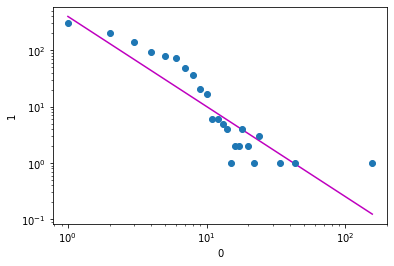

In [328]:
df = pd.DataFrame(outs)
df.iloc[1:].plot.scatter(x = 0, y = 1, loglog=True)
x=np.array(list(df[0][1:]))
y=np.array(list(df[1][1:]))
plt.loglog(x, 4*10**2/x**1.6, "-m",x, y, 'o')

Does that look like a power law degree distribution?

We can see that the out-degrees follow a power law distribution of slope 1.6.

* If you were to draw a straight line through the plot, approximating the data points, what
would the slope of that line be, approximately?
* Following the above example, **compile a histogram of the in-degrees** of the graph `G`,
discard the $0$-degree nodes, and then create a loglog plot of the remaining data points.
* If you were to draw a straight line through the plot, approximating the data points, what
would the slope of that line be, approximately?
* Can you go back in time and recover the state of the network at the end of $1998$ (as a subgraph `G0`
of `G`)?  If so, for articles published from $1999$ onwards, determine the frequency of
articles in `G0` being cited, in relation to their degree in `G0`, and plot
the result in a meaningful way.

(To enable input for the text cell below, highlight the cell and press return.
To typeset the text nicely, and disable input, type SHIFT-return.)

In [329]:
ins = {}
for (n, d) in G.in_degree():
    ins[d] = ins.get(d, 0) + 1

ins = list(ins.items())
ins.sort()
print(ins)

[(0, 602), (1, 322), (2, 224), (3, 141), (4, 93), (5, 50), (6, 47), (7, 44), (8, 36), (9, 15), (10, 15), (11, 8), (12, 12), (13, 7), (14, 10), (15, 4), (16, 2), (17, 4), (18, 5), (19, 2), (20, 1), (22, 2), (23, 1), (24, 1), (27, 1), (28, 1), (29, 1), (30, 1), (39, 1), (59, 1), (71, 1)]


<AxesSubplot:xlabel='0'>

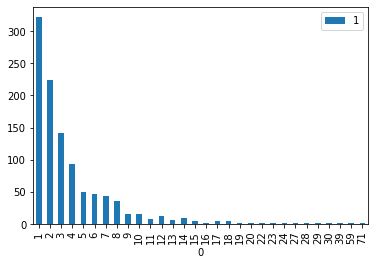

In [330]:
df = pd.DataFrame(ins)
df.iloc[1:].plot.bar(x = 0, y = 1)

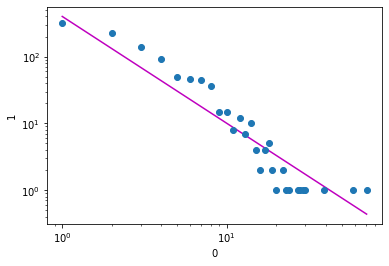

In [331]:
df = pd.DataFrame(ins)
df.iloc[1:].plot.scatter(x = 0, y = 1, loglog=True)
x=np.array(list(df[0][1:]))
y=np.array(list(df[1][1:]))
plt.loglog(x, 4*10**2/x**1.6, "-m",x, y, 'o')

We can see that the in-degrees distribution can be fitted with a straight line of slope 1.6.

In [332]:
nodes0 = [x for x in G if G.nodes[x].get('year', 0) < 1999]
G0 = G.subgraph(nodes0)
G0.order(), G0.size()

(1202, 2088)

In [333]:
for x in G0:
    G0.nodes[x]['citations'] = 0

for x in G:
    if G.nodes[x].get('year') == None:
        continue
    if G.nodes[x].get('year') > 1998:
        for y in G[x]:
            if y in G0:
                G0.nodes[y]['citations'] += 1

In [334]:
nr = {}
cd = {}
for x in G0:
    d = G0.in_degree(x)
    nr[d] = nr.get(d, 0) + 1
    cd[d] = cd.get(d, 0) + G0.nodes[x]['citations']
print(cd)

{7: 32, 4: 100, 3: 71, 0: 486, 23: 13, 17: 10, 12: 32, 1: 256, 15: 15, 8: 39, 2: 188, 9: 8, 10: 21, 5: 46, 6: 65, 14: 5, 21: 6, 36: 23, 13: 10, 20: 2, 49: 22, 25: 14, 11: 22}


In [335]:
avg = { d: cd[d]/nr[d] for d in cd }

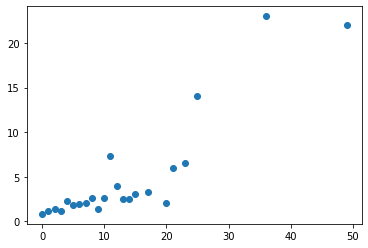

In [336]:
plt.scatter(avg.keys(), avg.values())

Although the plot is not a straight line, we can still see nodes that were highly cited in 1998 tend to receive even more citations in the years since.

### 2. Configuration Model

A configuration model for a given list of stubs (half-edges) can be produced with the following `python` program:

In [337]:
import random

def configuration_stubs(stubs):
    m = len(stubs) // 2  # should check if sum(degrees) is even ...
    random.shuffle(stubs)
    G = nx.Graph(zip(stubs[:m], stubs[m:]))
    G.remove_edges_from(nx.selfloop_edges(G))
    return G

The following function produces a list of stubs from a list `a` of degrees:

In [338]:
def stubs_list(a):
    return sum([d * [i] for i, d in enumerate(a)], [])

So we can start with a list `dd` of degrees, convert this into a list of stubs and then
create a graph `G` with the given list of node degrees (up to self-loops and multiple edges).

In [339]:
dd = [3, 2, 2, 1, 1, 1]
stubs = stubs_list(dd)
G = configuration_stubs(stubs)
print(sum(dd)//2, G.size())

5 5


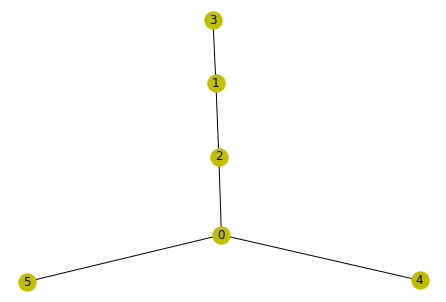

In [340]:
nx.draw(G, **opts)

Conversely, we can use `collections.Counter` to recover the list of degrees from the list of stubs:

In [341]:
stubs

[3, 0, 0, 4, 2, 1, 5, 2, 0, 1]

In [342]:
from collections import Counter

In [343]:
k = Counter(stubs)
print(k)

Counter({0: 3, 2: 2, 1: 2, 3: 1, 4: 1, 5: 1})


The following function produces a list of stubs, whose corresponding list of degrees is
distributed according to a power law $p_k = n_k/n \approx c k^{-\gamma}$ with parameter
$\gamma = \frac{2-p}{1-p}$.

In [344]:
def powerstubs(m, p):
    
    # distribute 2*m according to a power law
    l = 0
    x = [l]
    for i in range(2*m-1):
        if random.random() < p:
            l += 1
            x.append(l)
        else:
            k = random.choice(x)
            x.append(k)
            
    return x

In [345]:
stubs = powerstubs(10, 1/2)
stubs

[0, 1, 2, 1, 2, 2, 3, 1, 1, 2, 4, 5, 6, 7, 2, 8, 2, 2, 9, 3]

In [346]:
degrees = list(Counter(stubs).values())
degrees

[1, 4, 7, 2, 1, 1, 1, 1, 1, 1]

* Construct a list `stubs` and a corresponding list of approximately $n = 5000$ `degrees` such that
  the distribution of the values in `degrees` follows a power law.
* What is the value of $\gamma$ in this power law?
* Use the above function `configuration_stubs` to create
  a **random network** `C` with degree sequence `degree`.
* How many nodes and edges do you expect, how many nodes and edges does the graph
  `C` actually have?
* In `networkx`, a configuration model can be generated with the function 
  `nx.configuration_model(degrees)`.  Apply this function to the same degree
  sequence to obtain a random network `D`.   How many nodes and edges does
  the graph `D` have?
* Can you draw a loglog plot that provides evidence for `D` having a power law
  degree distribution?

(If $n = 5000$ turns out to be to large, use a smaller number of nodes.)

In [347]:
stubs = powerstubs(5000, 0.5)
k = Counter(stubs)

In [348]:
degrees = list(Counter(stubs).values())

$\gamma = \frac{2-p}{1-p} = \frac{2-0.5}{1-0.5} = 3$

In [349]:
C=configuration_stubs(stubs)

With probability of 0.5 and 10000 stubs, I expect 5000 edges and approximately 5000 nodes.

In [350]:
print("No. of nodes in C:", C.number_of_nodes())
print("No. of edges in C:", C.size())

No. of nodes in C: 5019
No. of edges in C: 4982


In [351]:
D= nx.configuration_model(degrees)

In [352]:
print("No. of nodes in D:", D.order())
print("No. of edges in D:", D.size())

No. of nodes in D: 5019
No. of edges in D: 5000


<AxesSubplot:xlabel='0', ylabel='1'>

<Figure size 1440x720 with 0 Axes>

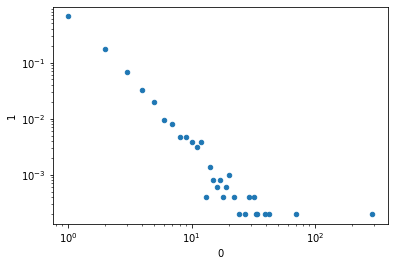

In [353]:
hist = nx.degree_histogram(D)
data= [(i, v/D.order()) for i, v in enumerate(hist) if v > 0]
plt.figure(figsize=(20,10))
pd.DataFrame(data).plot.scatter(x= 0, y = 1, loglog= True)

We can see from the straight-lined loglog plot that the degrees of D follow a power law distribution.

### 3. Preferential Linear Attachment

The following algorithm, introduced and named after Barabási-Albert, **grows** a network
on $n$ nodes from a complete graph on $a$ nodes, by
adding one node at a time, together with $b$ new edges, linking the new node to 
$b$ old nodes, with a probability given by their current degrees:

An $(n, a, b)$**-BA model** is a (simple) graph on $n$ nodes, constructed as follows.
1. start with a complete graph on $a$ nodes (at time $t = 0$)
2. for $t = 1, \dots, n-a-1$:
    * add new node $x = a + t$
    * and $b$ links to old nodes $i$ with probability 
      $$
      p_{x \to i} = \frac{k_{i, t-1}}{2 m_{t-1}},
      $$
      where $k_{i,t}$ is the degree of node $i$ at time $t$ and $m_t$ is the
      number of edges at time $t$.

For an implementation of this algorithm, we need to be able to draw $m$ items from the current
list of nodes, where each node is picked with a probability proportional to its current degree
This functionality is provided by the function `random.choices`,

In [354]:
import random

To pick $4$ from $0,\dots,5$ with a large bias towards $5$:

In [355]:
sorted(random.choices(range(6), 5*[1] + [5], k=4))

[4, 5, 5, 5]

No we are ready to grow a graph.  Let's set $a = 3$ and $b = 2$ for starters.

In [356]:
a, b = 3, 2

In [357]:
G = nx.complete_graph(a)
G.degree()

DegreeView({0: 2, 1: 2, 2: 2})

In [358]:
x, m = G.order(), G.size()
x, m

(3, 3)

Compute a discrete probabilty distribution corresponding to node degrees.

In [359]:
degrees = [d for n, d in G.degree()]
degrees

[2, 2, 2]

Select $b$ distinct nodes from the old graph according to the probabilities `prob`

In [360]:
old = sorted(random.choices(list(G.nodes()), degrees, k=b))
old

[0, 1]

Add edges from a new node `x` to the selected nodes.

In [361]:
G.add_edges_from([(x, o) for o in old])

Draw the resulting graph.

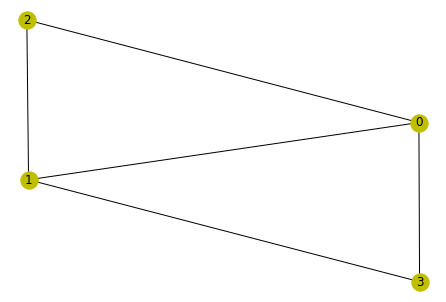

In [362]:
nx.draw(G, **opts)

For the next node, all of the previous steps are repeated.

In [363]:
x, m  = G.order(), G.size()
degrees = [d for n, d in G.degree()]
old = sorted(random.choices(list(G.nodes()), degrees, k=b))
G.add_edges_from([(x, o) for o in old])

And again, we can draw the resulting graph.

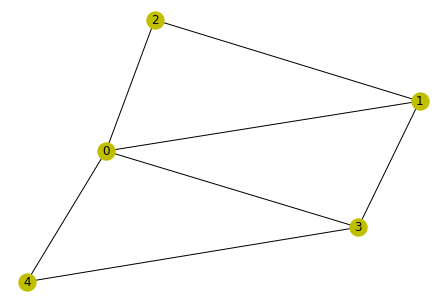

In [364]:
nx.draw(G, **opts)

And so on ...

* Add 20 more nodes to the graph `G` by repeating the above steps
  and draw the resulting graph.
* Add 250 more nodes to the graph `G` by repeating the above steps
  (preferrably with a python `for` loop, rather than typing out 250 identical pieces of code.)
* Compute the graph clustering coefficient $C$ and the characteristic path length $L$ of `G`.
  How do these values compare to ER-random graphs of similar size?
* Create a loglog plot of the degree histogram of the final version of `G`: does this
  indicate a power law distribution?  If so, what is the exponent $\gamma$?
* In `networkx`, a BA-model can be generated with the function
  `nx.barabasi_albert_graph(n, b)` (where $a = b$ in terms of our parameters, and the initial
  graph is an **empty** graph on $a$ nodes).  Use this function to generate a graph `B`
  comparable to `G` above, and check whether its degree distribution follows a power law.

In [365]:
for i in range(20):
    x, m  = G.order(), G.size()
    degrees = [d for n, d in G.degree()]
    old = sorted(random.choices(list(G.nodes()), degrees, k=b))
    G.add_edges_from([(x, o) for o in old])

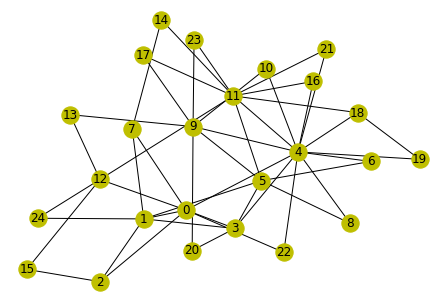

In [366]:
nx.draw(G, **opts)

In [367]:
for i in range(250):
    x, m  = G.order(), G.size()
    degrees = [d for n, d in G.degree()]
    old = sorted(random.choices(list(G.nodes()), degrees, k=b))
    G.add_edges_from([(x, o) for o in old])

In [368]:
print("Clustering coefficient of G:", nx.average_clustering(G))
print("Characteristic path length of G:", nx.average_shortest_path_length(G))

Clustering coefficient of G: 0.049467121991448204
Characteristic path length of G: 3.5519575315195753


In [369]:
while True:
    ER = nx.gnm_random_graph(G.order(), G.size())
    if nx.is_connected(ER):
        break

In [370]:
print("Clustering coefficient of random graph:", nx.average_clustering(ER))
print("Characteristic path length of random graph:", nx.average_shortest_path_length(ER))

Clustering coefficient of random graph: 0.025076479076479065
Characteristic path length of random graph: 4.285653616456536


We see that  G has a higher graph clustering coefficient and a smaller characteristic path length of random graphs of a similar size.

<Figure size 1440x720 with 0 Axes>

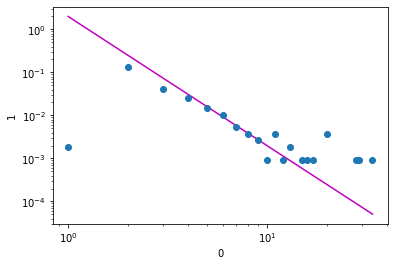

In [371]:
hist = nx.degree_histogram(G)
m2 = 2*G.size()
data = [(i, v/m2) for i, v in enumerate(hist) if v > 0] 
plt.figure(figsize=(20,10)) 
pd.DataFrame(data).plot.scatter(x = 0, y = 1, loglog=True)
x,y= zip(*data)
x = np.array(x)
y=np.array(y)
plt.loglog(x, 2*10**0/x**3, "-m",x, y, 'o')

The exponent $\gamma$ is approximately 3.

In [374]:
BA = nx.barabasi_albert_graph(G.order(), b)

<AxesSubplot:xlabel='0', ylabel='1'>

<Figure size 1440x720 with 0 Axes>

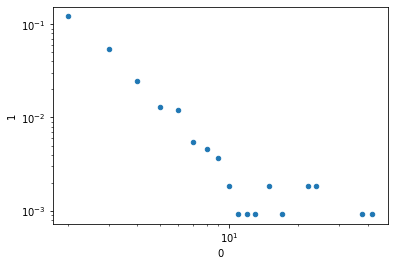

In [375]:
hist = nx.degree_histogram(BA)
m2 = 2*BA.size()
data = [(i, v/m2) for i, v in enumerate(hist) if v > 0] 
plt.figure(figsize=(20,10)) 
pd.DataFrame(data).plot.scatter(x = 0, y = 1, loglog=True)

We can see from the straight loglog plot that the degrees of the BA graph follow a power law distribution.

### 4. Course Summary

* In your own words, summarize the contents of the course.  What is Network Science?  Which parts are covered in the course, which are missing?  Use complete sentences.  Write approximately 100 words.


Network Science involves using networks (or graphs) to represent systems coomposed of elements and through this abstraction we can identify how the connectivity between elements in the system effects how the system behaves.

This module develops our understanding of important terminology required to discuss networks (e.g. degree, adjacency matrix), analyse (breadth/depth first search) and classify networks (centrality, transitivity). We apply this knowledge and generate, visualise and investigate different networks using python packages and functions.

In this module we have modelled networks using common random models such as Edos-Renyi, applied our tools to identify the characteristics of these networks and compared these to real-life examples of networks. For example, with sufficiently large N we found that the Erdos-Reyni model followed a Poisson distribution while many real-life networks follow a power law distribution with high clustering coefficients and short characteristic path lengths. We then built on our understanding and to generate graphs with similar attributes to many real-life graphs.

One aspect of network science that hasn't been covered in the course is the concept of a weighted graph.


